In [9]:
# Import Library yang dibutuhkan
import pickle # menggunakan pickle untuk load data
import sys # menggunakan sys untuk mengatasi error pada versi pandas terbaru
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_reliable = pd.read_pickle('../data/wm811k_v3_reliable.pkl')
print(f"Loaded: {df_reliable.shape[0]} baris, {df_reliable.shape[1]} kolom")

Loaded: 809424 baris, 25 kolom


In [10]:
# mari kita validasi struktur data sebelum mulai eksplorasi lebih lanjut
try:
    print(f"Total baris di df_reliable: {len(df_reliable)}")
except NameError:
    print("ERROR: df_reliable tidak ditemukan! Kernel mungkin di-restart.")
    print("Solusi: Run ulang cell di Day 12 yang membuat df_reliable.")

Total baris di df_reliable: 809424


In [11]:
# apakah failure_type_clean ada dan sesuai
try:
    print("Kategori failureType_clean:")
    print(df_reliable['failureType_clean'].value_counts())
except KeyError:
    print("ERROR: Kolom 'failureType_clean' tidak ada di df_reliable!")
    print("Solusi: Cek nama kolom kamu di Day 12, mungkin namanya 'failureType' atau 'failure_Type'.")

Kategori failureType_clean:
failureType_clean
none         783905
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [12]:
# apakah 4 kolom metric numerik sudah ada
required_cols = ['density_global', 'density_center', 'density_edge', 'edge_center_diff']
available_cols = [c for c in df_reliable.columns if 'density' in c or 'edge_center' in c]
print(f"Kolom density/edge yang tersedia: {available_cols}")

Kolom density/edge yang tersedia: ['density_global_reliable', 'density_regional_reliable', 'density_global', 'density_center', 'density_edge', 'edge_center_diff']


In [13]:
# Cek apakah ada yang hilang dari requirement kita
missing_cols = [col for col in required_cols if col not in available_cols]
if missing_cols:
    print(f"\nWARNING: Kolom ini TIDAK DITEMUKAN: {missing_cols}")
    print("Solusi: Kamu harus kembali ke proses feature engineering Day 12 dan buat kolom ini.")
else:
    print("\nSEMUA AMAN! 4 kolom metric numerik siap dipakai untuk pivot_table.")


SEMUA AMAN! 4 kolom metric numerik siap dipakai untuk pivot_table.


In [15]:
summary_pivot = pd.pivot_table(
    df_reliable,
    index='failureType_clean',
    values=['density_global', 'density_center', 'density_edge', 'edge_center_diff'],
    aggfunc=['mean', 'count'],
    margins=True,
    margins_name='All'
)
print(summary_pivot.round(3))

                            mean                                               \
                  density_center density_edge density_global edge_center_diff   
failureType_clean                                                               
Center                     0.243        0.221          0.232           -0.022   
Donut                      0.367        0.172          0.277           -0.195   
Edge-Loc                   0.124        0.257          0.183            0.133   
Edge-Ring                  0.059        0.258          0.151            0.199   
Loc                        0.145        0.156          0.150            0.012   
Near-full                  0.898        0.852          0.877           -0.046   
Random                     0.468        0.493          0.481            0.025   
Scratch                    0.081        0.125          0.101            0.043   
none                       0.072        0.118          0.093            0.046   
All                        0

In [18]:
# Langkah 3: Sanity Check

# 1. Re-create diff_stats (karena di notebook baru variabel ini belum ada)
# Ini menghitung statistik deskriptif edge_center_diff menggunakan groupby langsung
diff_stats = df_reliable.groupby('failureType_clean')['edge_center_diff'].describe()

print("=== 1. Perbandingan Mean edge_center_diff ===")
print("Dari Pivot Table:")
print(summary_pivot['mean']['edge_center_diff'])
print("\nDari GroupBy Describe (diff_stats):")
print(diff_stats['mean'])

print("\n===========================================\n")

# 2. Cek total count
print("=== 2. Validasi Total Count ===")
total_count_pivot = summary_pivot['count']['density_global']['All']
total_baris_data = len(df_reliable)

print(f"Total count dari Pivot Table (baris 'All'): {total_count_pivot}")
print(f"Total baris df_reliable (len): {total_baris_data}")

# Cek apakah identik
match_count = total_count_pivot == total_baris_data
print(f"Apakah total count match? {match_count}")

# Cek apakah mean edge_center_diff match
# Kita buang baris 'All' dulu dari pivot agar bisa dibandingkan dengan diff_stats
mean_pivot_clean = summary_pivot['mean']['edge_center_diff'].drop('All')
mean_groupby_clean = diff_stats['mean']

# Sort index biar urutannya sama sebelum dibandingkan
mean_pivot_sorted = mean_pivot_clean.sort_index()
mean_groupby_sorted = mean_groupby_clean.sort_index()

# Cek selisihnya, kalau 0 berarti identik
selisih = (mean_pivot_sorted - mean_groupby_sorted).sum()
print(f"Apakah mean edge_center_diff match? (selisih harus 0): {selisih < 1e-9}")

=== 1. Perbandingan Mean edge_center_diff ===
Dari Pivot Table:
failureType_clean
Center      -0.022341
Donut       -0.194776
Edge-Loc     0.132926
Edge-Ring    0.199250
Loc          0.011851
Near-full   -0.045780
Random       0.024610
Scratch      0.043402
none         0.045970
All          0.047638
Name: edge_center_diff, dtype: float64

Dari GroupBy Describe (diff_stats):
failureType_clean
Center      -0.022341
Donut       -0.194776
Edge-Loc     0.132926
Edge-Ring    0.199250
Loc          0.011851
Near-full   -0.045780
Random       0.024610
Scratch      0.043402
none         0.045970
Name: mean, dtype: float64


=== 2. Validasi Total Count ===
Total count dari Pivot Table (baris 'All'): 809424
Total baris df_reliable (len): 809424
Apakah total count match? True
Apakah mean edge_center_diff match? (selisih harus 0): True


In [ ]:
size_interaction = pd.pivot_table(
    df_reliable,
    index='failureType_clean',
    columns='dieSize_binned',
    values='density_global',
    aggfunc='mean',
    observed=True
)
print(size_interaction.round(3))

# hitung juga count-nya, biar tau kalau ada sel yang isinya cuma segelintir baris (mean-nya gak reliable)
size_interaction_count = pd.pivot_table(
    df_reliable,
    index='failureType_clean',
    columns='dieSize_binned',
    values='density_global',
    aggfunc='count',
    observed=True
)
print("\nJumlah baris per sel:")
print(size_interaction_count)

dieSize_binned     kecil  sedang  besar
failureType_clean                      
Center             0.275   0.187  0.063
Donut              0.304   0.269  0.350
Edge-Loc           0.241   0.167  0.116
Edge-Ring          0.187   0.190  0.117
Loc                0.199   0.148  0.058
Near-full          0.886   0.869  0.916
Random             0.498   0.478  0.429
Scratch            0.145   0.107  0.047
none               0.138   0.092  0.045

Jumlah baris per sel:
dieSize_binned      kecil  sedang   besar
failureType_clean                        
Center               2521    1554     219
Donut                  17     490      48
Edge-Loc             1480    3211     498
Edge-Ring             357    4176    5147
Loc                   919    2239     435
Near-full              64      83       2
Random                212     618      36
Scratch               249     655     289
none               214989  372734  196182


In [20]:
def top_n_density(group, n=3):
    """
    Ambil n baris dengan density_global tertinggi dari satu grup.
    Aman lewat groupby().apply() karena tidak pernah mereferensikan
    kolom grouping (failureType_clean) di dalam body fungsi.
    """
    return group.nlargest(n, 'density_global')

In [21]:
# Simpan kolom yang relevan buat kandidat visual Day 14
# (waferMap ikut disimpan supaya bisa langsung diplot nanti,
#  tanpa perlu query ulang ke df_reliable)
cols_needed = ['lotName', 'waferIndex', 'waferMap',
               'density_global', 'density_center', 'density_edge',
               'edge_center_diff']

top3_per_category = df_reliable[cols_needed].groupby(
    df_reliable['failureType_clean'], observed=True
).apply(top_n_density, include_groups=False)

print(top3_per_category[['density_global', 'density_center', 'density_edge', 'edge_center_diff']])

                          density_global  density_center  density_edge  \
failureType_clean                                                        
Center            573           0.727142        0.961776      0.397924   
                  1097          0.717783        0.967941      0.366782   
                  1959          0.706983        0.964242      0.346021   
Donut             4674          0.678411        0.792593      0.561457   
                  4640          0.651032        0.641221      0.660517   
                  4689          0.637524        0.779555      0.457701   
Edge-Loc          6035          0.746124        0.797872      0.683761   
                  7851          0.719493        0.713996      0.725469   
                  7533          0.719444        0.753311      0.676471   
Edge-Ring         13835         0.451005        0.289786      0.632000   
                  17890         0.437186        0.282660      0.610667   
                  15906         0.4321

In [23]:
# Validasi: Pastikan setiap kategori menghasilkan tepat 3 baris
print("=== Jumlah baris per kategori (Harusnya 3 semua) ===")
print(top3_per_category.index.get_level_values(0).value_counts())

print("\n=== Cek apakah benar ini density tertinggi ===")
# Bandingkan dengan max density global per kategori dari df_reliable asli
max_density_original = df_reliable.groupby('failureType_clean')['density_global'].max()
max_density_top = top3_per_category['density_global'].reset_index().groupby('failureType_clean')['density_global'].max()

comparison = (max_density_original == max_density_top)
print(f"Apakah max density di top3 match dengan df_reliable asli? \n{comparison}")
print(f"Semua True? {comparison.all()}")

=== Jumlah baris per kategori (Harusnya 3 semua) ===
failureType_clean
Center       3
Donut        3
Edge-Loc     3
Edge-Ring    3
Loc          3
Near-full    3
Random       3
Scratch      3
none         3
Name: count, dtype: int64

=== Cek apakah benar ini density tertinggi ===
Apakah max density di top3 match dengan df_reliable asli? 
failureType_clean
Center       True
Donut        True
Edge-Loc     True
Edge-Ring    True
Loc          True
Near-full    True
Random       True
Scratch      True
none         True
Name: density_global, dtype: bool
Semua True? True


In [24]:
anomaly_check = df_reliable.loc[[174568, 174684, 177113],
    ['lotName', 'waferIndex', 'trainTestLabel_clean', 'stratify_key', 'dieSize', 'fill_ratio']]
print(anomaly_check)

         lotName  waferIndex trainTestLabel_clean stratify_key  dieSize  \
174568   lot2757          20                 none    unlabeled     2950   
174684   lot1846          21                 none    unlabeled      693   
177113  lot23834           8                 none    unlabeled      655   

        fill_ratio  
174568    0.769431  
174684    0.770000  
177113    0.324097  


In [25]:
threshold = 0.8

unlabeled_extreme = df_reliable[
    (df_reliable['stratify_key'] == 'unlabeled') &
    (df_reliable['density_global'] >= threshold)
]
reviewed_extreme = df_reliable[
    (df_reliable['stratify_key'] == 'reviewed_no_defect') &
    (df_reliable['density_global'] >= threshold)
]

n_unlabeled = (df_reliable['stratify_key'] == 'unlabeled').sum()
n_reviewed = (df_reliable['stratify_key'] == 'reviewed_no_defect').sum()

print(f"Unlabeled, density >= {threshold}: {len(unlabeled_extreme)} / {n_unlabeled} ({len(unlabeled_extreme)/n_unlabeled*100:.3f}%)")
print(f"Reviewed_no_defect, density >= {threshold}: {len(reviewed_extreme)} / {n_reviewed} ({len(reviewed_extreme)/n_reviewed*100:.3f}%)")

Unlabeled, density >= 0.8: 2257 / 636499 (0.355%)
Reviewed_no_defect, density >= 0.8: 0 / 147406 (0.000%)


In [26]:
# Mask untuk wafer unlabeled dengan density >= 0.8
mask_anomali_unlabeled = (
    (df_reliable['stratify_key'] == 'unlabeled') & 
    (df_reliable['density_global'] >= 0.8)
)

print(f"Jumlah anomali unlabeled (density >= 0.8) yang akan dibuang: {mask_anomali_unlabeled.sum()}")

# Filter dataset bersih
df_clean_final = df_reliable[~mask_anomali_unlabeled].copy()

# Cek max density untuk kategori 'none' sekarang
max_none_final = df_clean_final[df_clean_final['failureType_clean'] == 'none']['density_global'].max()
print(f"\nMax density global untuk kategori 'none' setelah cleaning: {max_none_final:.4f}")

Jumlah anomali unlabeled (density >= 0.8) yang akan dibuang: 2257

Max density global untuk kategori 'none' setelah cleaning: 0.7999


In [27]:
def quantile_summary(group, col):
    """Ringkasan Q1/median/Q3/mean/n untuk satu kolom dalam satu grup."""
    return pd.Series({
        'q1': group[col].quantile(0.25),
        'median': group[col].quantile(0.50),
        'q3': group[col].quantile(0.75),
        'mean': group[col].mean(),
        'n': len(group)
    })

edge_center_q = df_reliable.groupby('failureType_clean', observed=True).apply(
    quantile_summary, col='edge_center_diff', include_groups=False
).sort_values('mean')

print(edge_center_q.round(4))

                       q1  median      q3    mean         n
failureType_clean                                          
Donut             -0.2798 -0.1862 -0.1027 -0.1948     555.0
Near-full         -0.1118 -0.0188  0.0190 -0.0458     149.0
Center            -0.0404  0.0095  0.0458 -0.0223    4294.0
Loc               -0.0132  0.0233  0.0627  0.0119    3593.0
Random            -0.0506  0.0281  0.1058  0.0246     866.0
Scratch            0.0165  0.0377  0.0655  0.0434    1193.0
none               0.0095  0.0361  0.0726  0.0460  783905.0
Edge-Loc           0.0888  0.1239  0.1668  0.1329    5189.0
Edge-Ring          0.1581  0.1910  0.2454  0.1993    9680.0


In [28]:
def find_split_threshold(sorted_q, gap_rank=0):
    """
    sorted_q: DataFrame hasil quantile_summary, sudah di-sort by 'mean'.
    gap_rank=0 -> gap terbesar, gap_rank=1 -> gap terbesar kedua, dst.
    Return: (threshold, kategori_bawah, kategori_atas)
    """
    gaps = sorted_q['mean'].diff().dropna()
    target_upper_cat = gaps.sort_values(ascending=False).index[gap_rank]
    pos = sorted_q.index.get_loc(target_upper_cat)
    lower_cat = sorted_q.index[pos - 1]

    threshold = (sorted_q.loc[lower_cat, 'q3'] + sorted_q.loc[target_upper_cat, 'q1']) / 2
    return threshold, lower_cat, target_upper_cat

thresh_center, cat_low, cat_high = find_split_threshold(edge_center_q, gap_rank=0)
print(f"THRESHOLD_CENTER = {thresh_center:.4f}  (gap {cat_low} vs {cat_high})")

thresh_edge, cat_low2, cat_high2 = find_split_threshold(edge_center_q, gap_rank=1)
print(f"THRESHOLD_EDGE   = {thresh_edge:.4f}  (gap {cat_low2} vs {cat_high2})")

THRESHOLD_CENTER = -0.1073  (gap Donut vs Near-full)
THRESHOLD_EDGE   = 0.0807  (gap none vs Edge-Loc)


In [30]:
density_q = df_reliable.groupby('failureType_clean', observed=True).apply(
    quantile_summary, col='density_global', include_groups=False
).sort_values('mean')

thresh_dense, cat_low3, cat_high3 = find_split_threshold(density_q, gap_rank=0)
print(f"THRESHOLD_DENSE (reproduced) = {thresh_dense:.4f}  (gap {cat_low3} vs {cat_high3})")

THRESHOLD_DENSE (reproduced) = 0.6752  (gap Random vs Near-full)


In [39]:
# 1. Pastikan df_reliable sudah ada di memori (bukan reimplementasi pipeline!)
#    Kalau belum ada, jangan reload+rekonstruksi manual di sini — itu berisiko
#    menghasilkan versi yang beda dari df_reliable resmi (notebook 02).
#    Cukup jalankan ulang cell pertama notebook ini (load dari pickle).
assert 'df_reliable' in globals(), \
    "df_reliable belum ada di memori — jalankan cell pertama " \
    "(pd.read_pickle('../data/wm811k_v3_reliable.pkl')) dulu, jangan skip."

# 2. Pilih kolom secara eksplisit, bukan select_dtypes otomatis
#    - waferIndex dibuang: cuma ID urutan, bukan fitur (korelasinya ~0 di semua baris,
#      cuma jadi noise di matriks/heatmap)
#    - total_cells dibuang: identik 1:1 dengan dieSize (r=1.00), redundan
cols_of_interest = [
    'dieSize', 'fill_ratio',
    'density_global', 'density_center', 'density_edge', 'edge_center_diff',
    'center_row', 'center_col'
]

corr_matrix = df_reliable[cols_of_interest].corr()

print("=== Matriks Korelasi (Pearson) ===")
print(corr_matrix.round(3))

=== Matriks Korelasi (Pearson) ===
                  dieSize  fill_ratio  density_global  density_center  \
dieSize             1.000       0.296          -0.229          -0.188   
fill_ratio          0.296       1.000          -0.321          -0.335   
density_global     -0.229      -0.321           1.000           0.970   
density_center     -0.188      -0.335           0.970           1.000   
density_edge       -0.249      -0.280           0.966           0.875   
edge_center_diff   -0.186       0.005           0.307           0.068   
center_row          0.946       0.312          -0.265          -0.223   
center_col          0.873       0.289          -0.276          -0.235   

                  density_edge  edge_center_diff  center_row  center_col  
dieSize                 -0.249            -0.186       0.946       0.873  
fill_ratio              -0.280             0.005       0.312       0.289  
density_global           0.966             0.307      -0.265      -0.276  
density

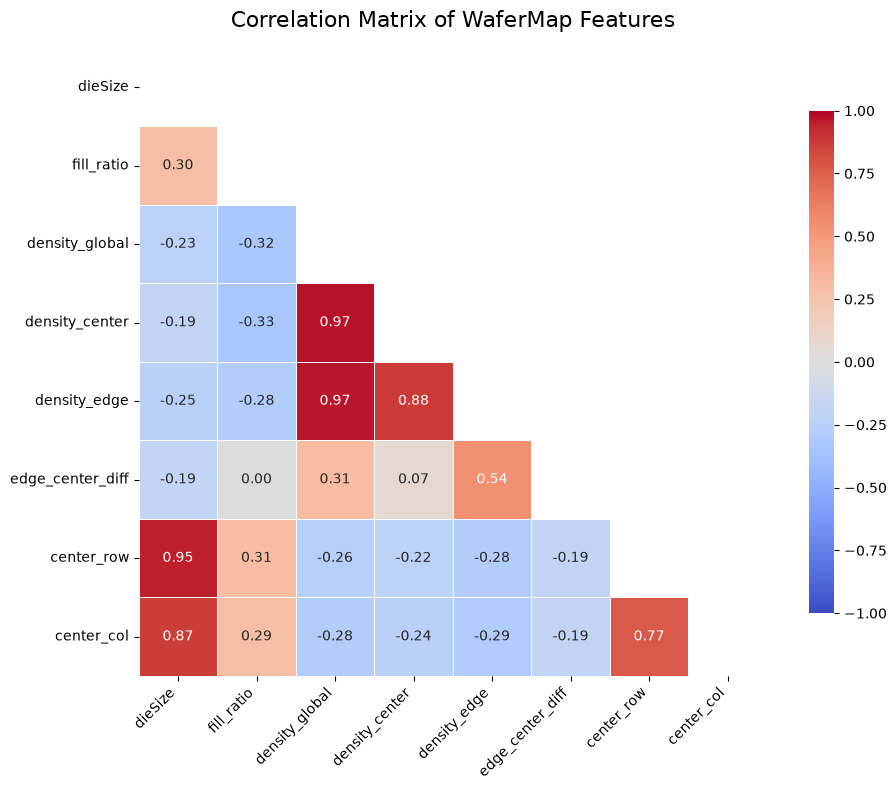

In [40]:
# 1.Setup figure size (diperbesar jadi 10x8 biar muat 10 kolom)
plt.figure(figsize=(10, 8))

# 2. Buat mask untuk membuang segitiga atas
# (Karena matriks korelasi itu simetris, kita cuma perlu lihat setengah bagian bawah)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3.Gambar heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,        # Tampilkan angka korelasinya di dalam kotak
    fmt=".2f",         # Format 2 angka di belakang koma
    cmap='coolwarm',   # Warna: biru (negatif), merah (positif)
    vmin=-1, vmax=1,   # Skala korelasi dari -1 sampai 1
    square=True, 
    linewidths=.5,
    cbar_kws={"shrink": .8} # Perkecil sedikit colorbar-nya
)

# 4.Kasih judul dan rapikan layout
plt.title('Correlation Matrix of WaferMap Features', fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right') # Putar label x biar tidak tabrakan
plt.yticks(rotation=0)
plt.tight_layout()

# 5. Tampilkan plot
plt.show()